In [29]:
import yfinance as yf
from scipy import stats
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [47]:
tickers=[
    "HCLTECH.NS","HDFCBANK.NS","HEROMOTOCO.NS","INDIGO.NS","INFY.NS","ITC.NS","KOTAKBANK.NS","SUNPHARMA.NS",
    "TATASTEEL.NS","TCS.NS"
    
]

data_raw = yf.download(tickers, period="2y",interval='1D',auto_adjust='True')

data_raw.head()
data_raw.to_csv('data_task2.csv')


[*********************100%***********************]  10 of 10 completed


In [39]:
data_raw.isnull().sum()
df=data_raw.ffill()
df.isnull().sum()


Price   Ticker       
Close   HCLTECH.NS       0
        HDFCBANK.NS      0
        HEROMOTOCO.NS    0
        INDIGO.NS        0
        INFY.NS          0
        ITC.NS           0
        KOTAKBANK.NS     0
        SUNPHARMA.NS     0
        TATASTEEL.NS     0
        TCS.NS           0
High    HCLTECH.NS       0
        HDFCBANK.NS      0
        HEROMOTOCO.NS    0
        INDIGO.NS        0
        INFY.NS          0
        ITC.NS           0
        KOTAKBANK.NS     0
        SUNPHARMA.NS     0
        TATASTEEL.NS     0
        TCS.NS           0
Low     HCLTECH.NS       0
        HDFCBANK.NS      0
        HEROMOTOCO.NS    0
        INDIGO.NS        0
        INFY.NS          0
        ITC.NS           0
        KOTAKBANK.NS     0
        SUNPHARMA.NS     0
        TATASTEEL.NS     0
        TCS.NS           0
Open    HCLTECH.NS       0
        HDFCBANK.NS      0
        HEROMOTOCO.NS    0
        INDIGO.NS        0
        INFY.NS          0
        ITC.NS           0
      

In [40]:
df_prices=df['Close']
df_prices.isnull().sum()

Ticker
HCLTECH.NS       0
HDFCBANK.NS      0
HEROMOTOCO.NS    0
INDIGO.NS        0
INFY.NS          0
ITC.NS           0
KOTAKBANK.NS     0
SUNPHARMA.NS     0
TATASTEEL.NS     0
TCS.NS           0
dtype: int64

In [119]:
df_returns=np.log(df_prices/df_prices.shift(1))
log_returns=df_returns.dropna()
log_returns.head()

Ticker,HCLTECH.NS,HDFCBANK.NS,HEROMOTOCO.NS,INDIGO.NS,INFY.NS,ITC.NS,KOTAKBANK.NS,SUNPHARMA.NS,TATASTEEL.NS,TCS.NS
Date,,,,,,,,,,
2024-05-15,0.008930,-0.015486,0.002742,0.035098,-0.003340,-0.004431,0.002730,-0.011619,0.003933,-0.005346
2024-05-16,0.011376,0.015007,0.016483,-0.001188,0.023250,0.008496,0.012790,0.005810,0.001810,0.012524
2024-05-17,-0.011151,0.002633,-0.010195,0.017536,-0.006247,0.011179,0.014546,-0.003195,0.008702,-0.017285
2024-05-21,0.006504,-0.003626,-0.006970,-0.011703,-0.007052,-0.003444,0.001002,0.006217,0.040977,-0.003632
2024-05-22,0.000857,0.000274,-0.011523,0.009284,0.014296,0.011661,0.000765,-0.001071,-0.006041,0.003084


In [122]:

    
def categorize_distribution(kurtosis):
    if kurtosis> 8:
        return "Extreme Fat-Tail"
    elif 6 < kurtosis <=8:
        return "High;y Leptokurtic (Fat-Tail)"
    elif 3 < kurtosis <=6:
        return "Moderatley Leptokurtic (Fat-Tail)"
    elif 1 < kurtosis <=3:
        return "Midly Leptokurtic (Fat-Tail)"
    elif -1  <= kurtosis <=1:
        return "Near Normal"
    else:
        return "Thin Tail (Platykurtic)"
        
summary_data = []
for stock in log_returns.columns:
    kurtosis = stats.kurtosis(log_returns[stock])
    volatility = log_returns[stock].std() * np.sqrt(252)
    skewness = stats.skew(log_returns[stock].dropna())
    
    summary_data.append({
        "Ticker": stock,
        "Volatility": f"{volatility:.1%}",
        "Skewness": round(skewness, 4),
        "Excess Kurtosis": round(kurtosis, 4),
        "Distribution": categorize_distribution(kurtosis)
    })

    
    

In [123]:
summary_table=pd.DataFrame(summary_data)
print(summary_table)

          Ticker Volatility  Skewness  Excess Kurtosis  \
0     HCLTECH.NS      25.8%   -0.9977           8.1043   
1    HDFCBANK.NS      20.2%   -0.2924           2.7745   
2  HEROMOTOCO.NS      26.3%    0.2895           1.0550   
3      INDIGO.NS      31.4%   -0.1668           2.4770   
4        INFY.NS      25.6%   -0.2776           3.2287   
5         ITC.NS      18.9%   -0.8455          12.0036   
6   KOTAKBANK.NS      22.2%    0.1309           5.5512   
7   SUNPHARMA.NS      20.3%   -0.0013           2.3993   
8   TATASTEEL.NS      29.4%   -0.5927           3.7904   
9         TCS.NS      22.0%   -0.1205           3.7454   

                        Distribution  
0                   Extreme Fat-Tail  
1       Midly Leptokurtic (Fat-Tail)  
2       Midly Leptokurtic (Fat-Tail)  
3       Midly Leptokurtic (Fat-Tail)  
4  Moderatley Leptokurtic (Fat-Tail)  
5                   Extreme Fat-Tail  
6  Moderatley Leptokurtic (Fat-Tail)  
7       Midly Leptokurtic (Fat-Tail)  
8  Moderat

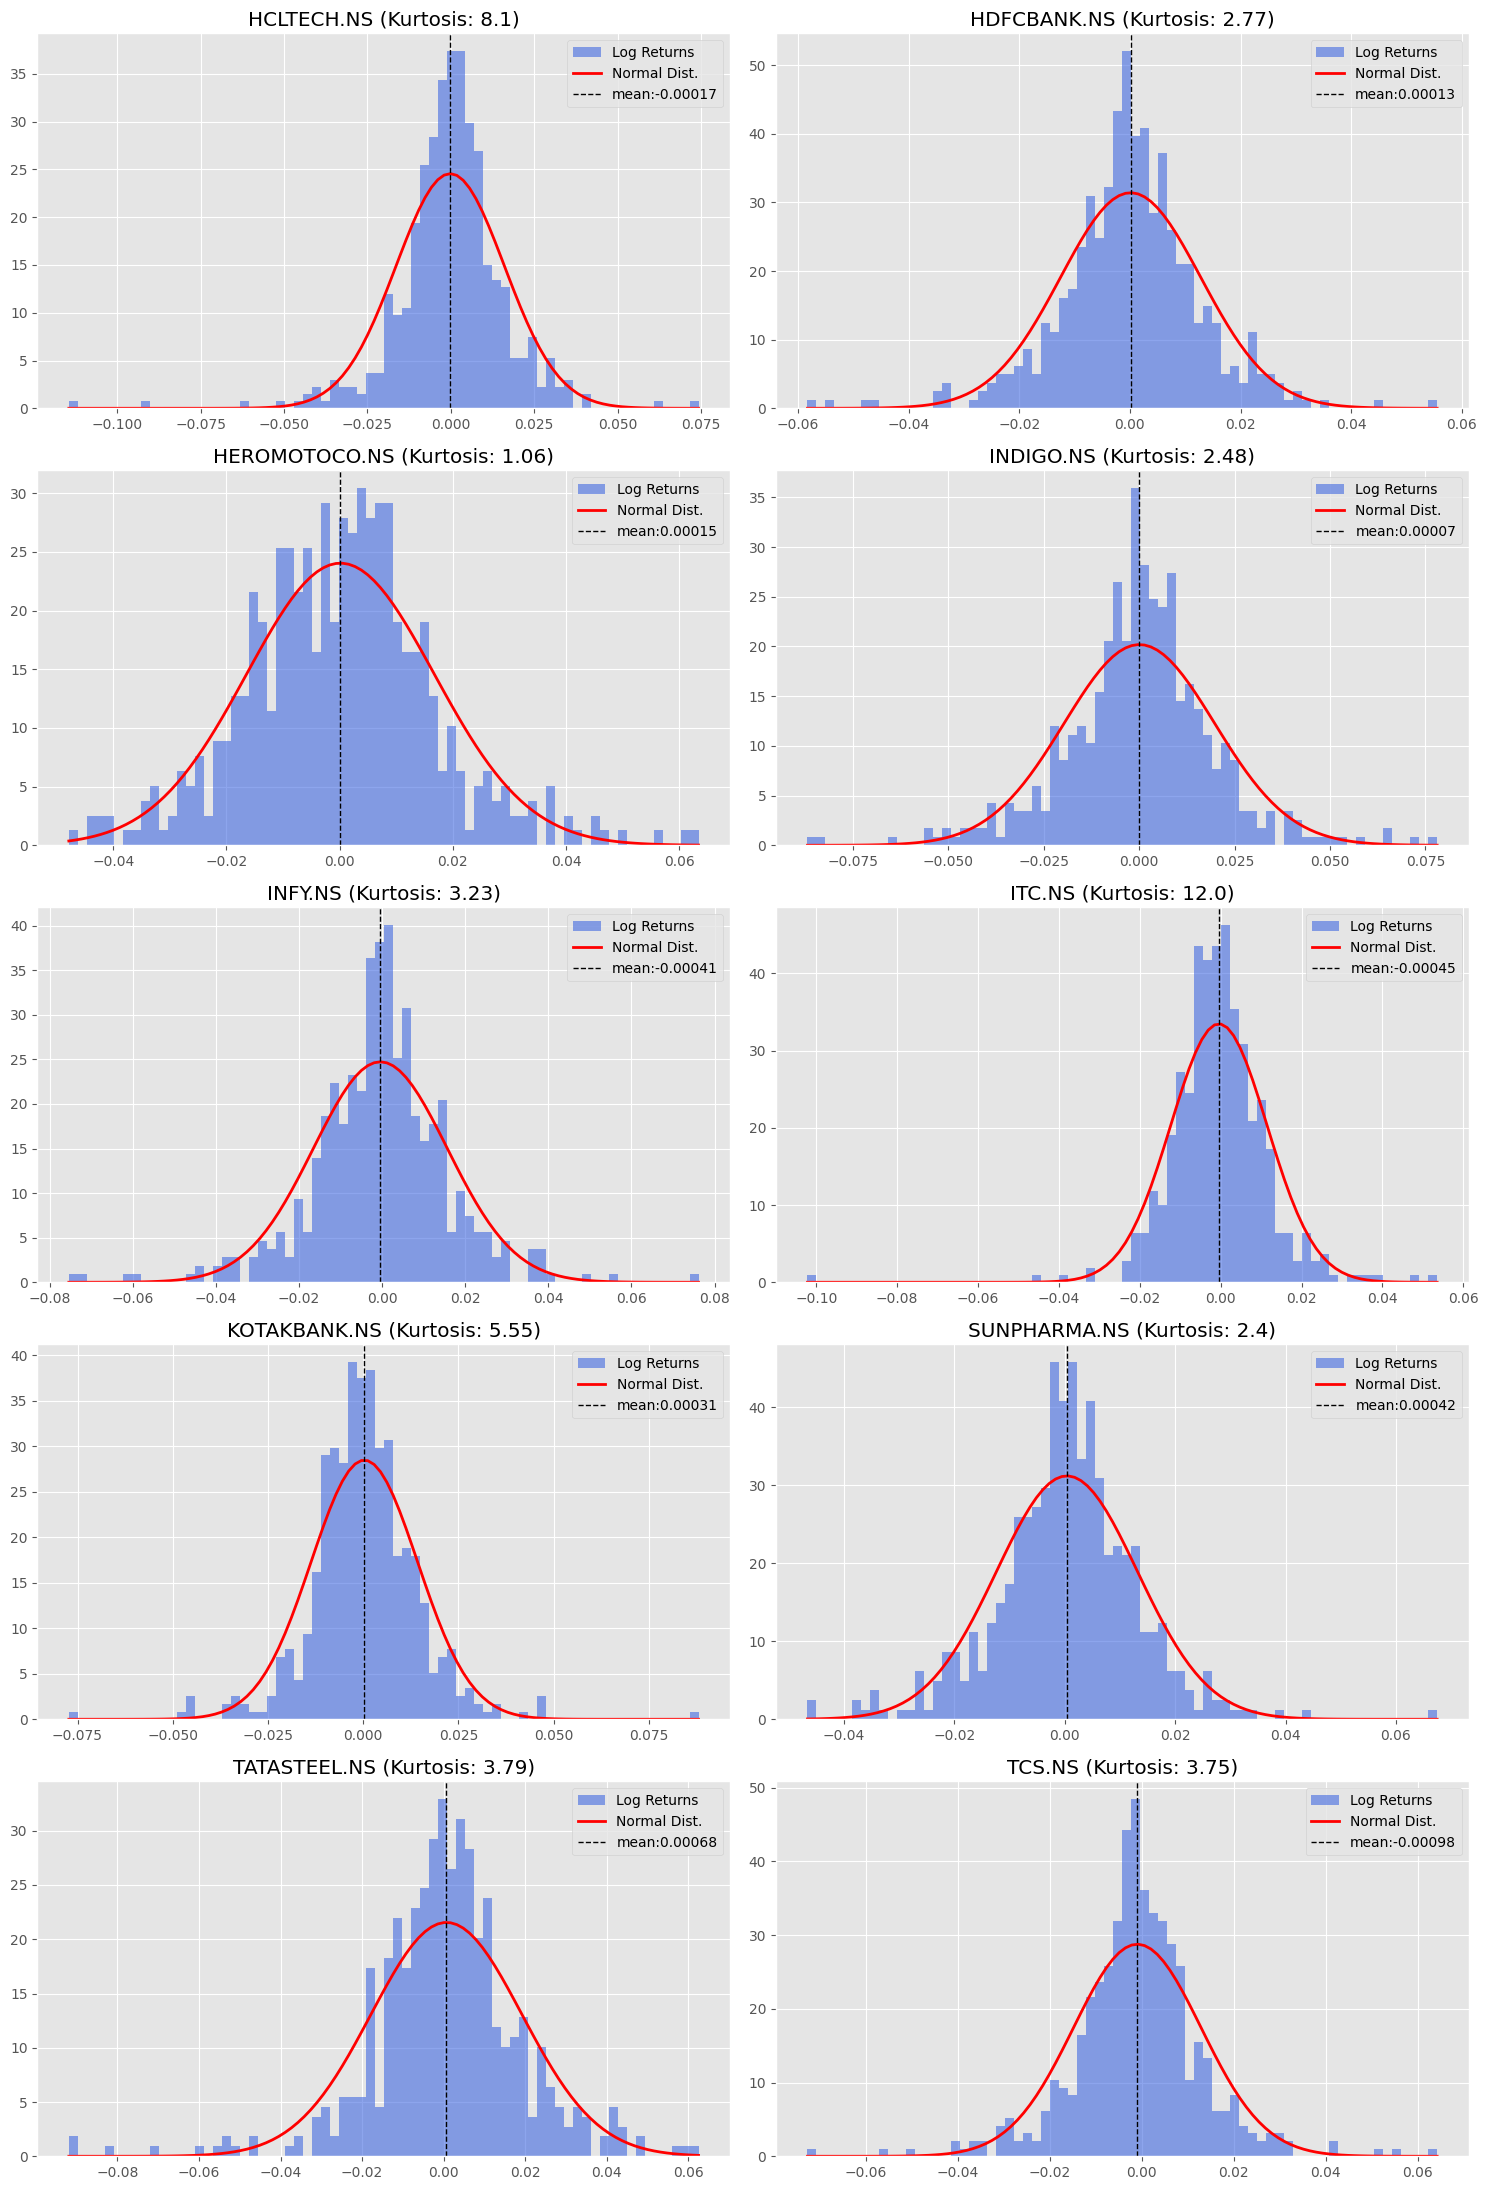

In [130]:
plt.style.use('ggplot')
fig, axes = plt.subplots(5, 2, figsize=(15, 22))
axes = axes.flatten()

for i, ticker in enumerate(tickers):
    returns = log_returns[ticker]
    ax = axes[i]
    ax.hist(returns, bins=70, density=True, alpha=0.6, color='royalblue', label='Log Returns')
    mu, std = returns.mean(), returns.std()
    x = np.linspace(returns.min(), returns.max(), 100)
    p = stats.norm.pdf(x, mu, std)
    ax.plot(x, p, 'r', linewidth=2, label='Normal Dist.')
    ax.set_title(f"{ticker} (Kurtosis: {round(stats.kurtosis(returns), 2)})")
    ax.axvline(mu,color='black',linestyle='--',label=f'mean:{mu:.5f}',linewidth=1)
    ax.legend()
plt.tight_layout()
plt.show()